# 第8章 自相关

## 8.5 处理自相关的Stata命令及实例

### 1. 时间序列算子

```
tsset year
```

- tsset表示time series set(时间序列集)，它告诉Stata，该数据集为时间序列，且时间变量为year

常用的时间序列算子包括滞后(lag)与差分(diference)，分别以“L.”与“D.”来表示(可以小写)。一阶滞后算子为“L.”，即$L.x_t=x_{t-1}$；二阶滞后算子为“L2.”,
即$L2.x_t=x_{t-2}$，以此类推。

如果要同时表示一阶至四阶滞后，可简写为“L(1/4).”，即$L(1/4).x_t=(x_{t-1}?x_{t-2}x_{t-3}x_{t-4})$。比如，以下命令：
```
reg y L.x L2.x L3.x L4.x
```
可以简写为：
```
reg y L(1/4).x
```

一阶差分算子为“D.”，即$D.x_t=\Delta x_t=x_t-x_{t-1}$；二阶差分算子为“D2.”，即$D2.x_t=\Delta(\Delta x)=\Delta(x_t-x_{t-1})=(x_t-x_{t-1})-(x_{t-1}-x_{t-2})=x_t-2x_{t-1}+x_{t-2}$(二阶差分为一阶差分的差分)。

“LD.”表示一阶差分的滞后值，“DL.”表示滞后值的一阶差分，二者实际上是等价的。因为$LD.x_t=L.(x_t-x_{t-1})=x_{t-1}-x_{t-2}=D.x_{t-1}=DL.x_t$

数据集icecream.dta包含了下列变量的30个月度时间序列数据：consumption(人均冰激凌消费量)，income(平均家庭收入)，price(冰激凌价格)，temp(平均华氏气温)，time(时间)。

In [1]:
* 首先，打开数据集，并将其设为时间序列数据。
use data/icecream.dta,clear
tsset time


Time variable: time, 1 to 30
        Delta: 1 unit


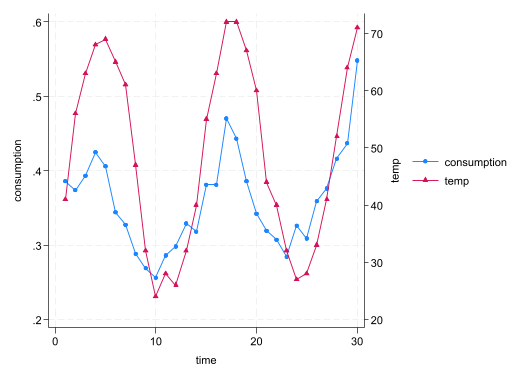

In [2]:
* 其次，为了看冰激凌的消费量与气温的时间趋势图，输入命令
* connect表示将观测点用线连接起来
* 选择项msymbol(circle)与msymbol(triangle)分别表示点的“图标”(marker symbol)为圆圈与三角形
* 选择项yaxis(1)与yaxis(2)指定使用不同的纵坐标，因为冰激凌消费量与气温的取值范围很不相同
twoway connect consumption time,msymbol(circle) yaxis(1) || connect temp time, msymbol(triangle) yaxis(2)

从上图可知，冰激凌消费量与气温明显地正相关。考虑以下线性回归模型：

$$
\text{consumption}_t=\beta_0+\beta_1\text{temp}_t+\beta_2\text{price}_t+\beta_3\text{income}_t+\epsilon_t
$$

In [3]:
* 首先进行OLS回归
reg consumption temp price income


      Source |       SS           df       MS      Number of obs   =        30
-------------+----------------------------------   F(3, 26)        =     22.17
       Model |  .090250523         3  .030083508   Prob > F        =    0.0000
    Residual |  .035272835        26  .001356647   R-squared       =    0.7190
-------------+----------------------------------   Adj R-squared   =    0.6866
       Total |  .125523358        29  .004328392   Root MSE        =    .03683

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |   .0034584   .0004455     7.76   0.000     .0025426    .0043743
       price |  -1.044413    .834357    -1.25   0.222    -2.759458    .6706322
      income |   .0033078   .0011714     2.82   0.009     .0008999    .0057156
       _cons |   .1973149   .2702161     0.73   0.

上表显示，气温(temp)与收入(income)的系数均在1%水平上显著为正，表示气温越高、收入越高，则冰激凌的消费量越大；价格(price)的系数为负，表明价格越高，则消费量越低，但并不显著(p值为0.222)。由于这是时间序列，我们怀疑其扰动项存在自相关。

### 2. 画残差图

假设在作完回归后，将残差记为e1，可输人如下命令画残差与其滞后的散点图
```
scatter e1 L.e1
```

如果想看残差自相关图(即各阶自相关系数)，可使用命令
```
ac e1
```
其中，“ac”表示autocorrelation(自相关)。

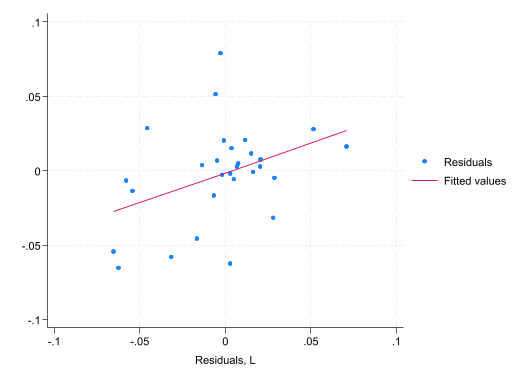

In [4]:
* 首先计算残差(记为e1)及其滞后值(L.e1)
predict e1,r
* 然后画残差与残差滞后的散点图
* “lfit”表示linear fit(线性拟合)，即画出e1与L.e1的拟合回归线
twoway scatter e1 L.e1 || lfit e1 L.e1

上图显示，扰动项很可能存在一阶正自相关。

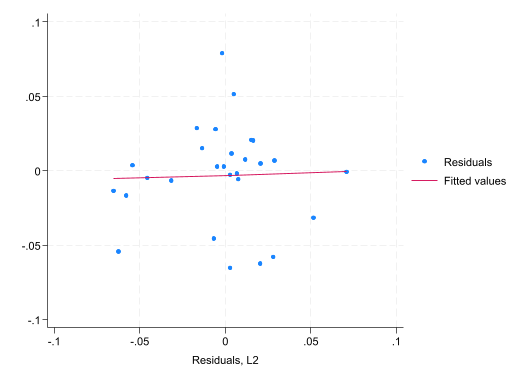

In [5]:
* 下面画残差与其二阶滞后的散点图
twoway scatter e1 L2.e1 || lfit e1 L2.e1

上图显示，残差似乎不存在二阶自相关(散点分布没有规律，且样本回归线的斜率接近于0)。

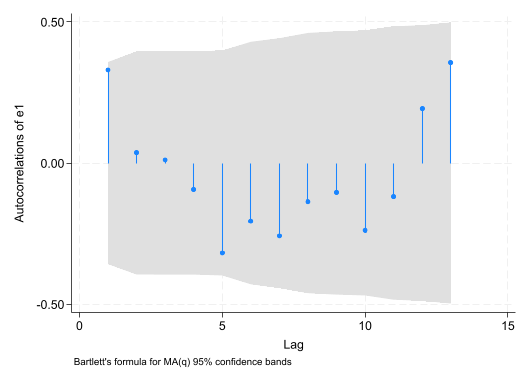

In [6]:
* 为了了解各阶自相关系数及其显著性，下面画残差的自相关图
ac e1

* 上图的横轴为滞后阶数，纵轴为残差的自相关系数，而阴影部分为置信度为95%
置信区间(区域)。
* 图中显示，各阶自相关系数的取值均在95%置信区间之内，故可接受各阶自相关系数为0的原假设。然而，一阶自相关系数已很接近置信区间的边界，故仍怀疑存在一阶自相关，而更高阶自相关则可大致忽略。

### 3.BG检验

作完 OLS 回归后，可使用如下命令进行 BG 检验
```
estat bgodfrey,lags(p) nomiss0
```
- 选择项“lags(p)”用来指定BG检验的滞后阶数p，默认“lags(1)”，即p=1;
- 选择项“nomiss0”表示进行不添加0的BG检验，默认以0代替缺失值，即Davidson-MacKinnon的方法。

如何确定滞后阶数p？一个简单方法是看自相关图。具体来说，在使用Stata命令ac
画自相关图时，所有落在95%置信区域(以阴影表示)以外的自相关系数均显著地不等于0。

确定滞后阶数p的另一方法是，设定一个较大的p值，作回归
$$
e_t=\gamma_1 e_{t-1}+\cdots+\gamma_p e_{t-p}+\delta_2 x_{t2}+\cdots+\delta_K x_{tK}+v_t \quad (t=p+1,\cdots,n)
$$
然后看最后一个系数$\gamma_p$的显著性；如果$\gamma_p$不显著，则考虑滞后(p-1)期，以此类推，直至显著为止。

In [7]:
* BG检验考察是否存在一阶自相关
estat bgodfrey


Breusch–Godfrey LM test for autocorrelation
---------------------------------------------------------------------------
    lags(p)  |          chi2               df                 Prob > chi2
-------------+-------------------------------------------------------------
       1     |          4.237               1                   0.0396
---------------------------------------------------------------------------
                        H0: no serial correlation


上表显示，BG检验的p值为0.0396，故可在5%显著性水平上拒绝“无自相关”的原假设，而认为存在自相关。

In [8]:
* 如果不以0取代缺失值，可输入命令
estat bgodfrey,nomiss0


Breusch–Godfrey LM test for autocorrelation
---------------------------------------------------------------------------
    lags(p)  |          chi2               df                 Prob > chi2
-------------+-------------------------------------------------------------
       1     |          4.704               1                   0.0301
---------------------------------------------------------------------------
                        H0: no serial correlation


结果依然可在5%水平上拒绝“无自相关”的原假设。

### 4. Q检验

假设将OLS残差记为e1，则可使用如下命令进行Q检验：
```
wntestq e1,lags(p)
```
- wntestq指white noise test Q,因为白噪声没有自相关。
- 选择项lags(p)用来指定滞后阶数，默认滞后阶数为$\min\{floor(n/2),40\}$

进行Q检验的另一命令是
```
corrgram e1,lags(p)
```
- corrgram表示correlogram，即画自相关图。
- 选择项lags(p)用来指定滞后阶数，而默认滞后阶数也是$\min\{floor(n/2),40\}$

In [9]:
wntestq e1


Portmanteau test for white noise
---------------------------------------
 Portmanteau (Q) statistic =    26.1974
 Prob > chi2(13)           =     0.0160


“Prob>chi2(13)=0.016”表明默认的滞后阶数为13阶，且可在5%水平上拒绝“无自相关”的原假设。

In [10]:
* 下面使用命令corrgram进行Q检验
corrgram e1


                                          -1       0       1 -1       0       1
 LAG       AC       PAC      Q     Prob>Q  [Autocorrelation]  [Partial autocor]
-------------------------------------------------------------------------------
1        0.3298   0.3969      3.6  0.0578          |--                |---     
2        0.0362  -0.1681    3.645  0.1616          |                 -|        
3        0.0111   0.0767   3.6494  0.3019          |                  |        
4       -0.0934  -0.1483   3.9715  0.4099          |                 -|        
5       -0.3186  -0.3565   7.8703  0.1635        --|                --|        
6       -0.2058   0.0011   9.5645  0.1442         -|                  |        
7       -0.2582  -0.4237   12.346  0.0897        --|               ---|        
8       -0.1373  -0.0721   13.169  0.1062         -|                  |        
9       -0.1035  -0.3300   13.658  0.1350          |                --|        
10      -0.2378  -0.8928   16.372  0.08

上表汇报了1-13阶的自相关系数(AC)，Q统计量(Q)及其相应p值(Prob>Q)。其中，第13阶Q统计量及其p值与命令wntestq的结果完全相同。

## 5. DW检验

In [11]:
estat dwatson


Durbin–Watson d-statistic(  4,    30) =  1.021169


由于DW统计量的局限性，Stata并未提供其临界值。但由于DW=1.02，离2较远而偏向0的方向，故可大致判断存在正自相关。

### 6.HAC稳健标准误

在Stata中进行OLS估计，但提供Newey-West标准误，可输入命令
```
newey y x1 x2 x3,lag(p)
```
- 必选项lag(p)用来指定截断参数p，即用于计算HAC标准误的最高滞后阶数。

由于扰动项存在自相关，故OLS估计所提供的标准误不准确，应使用异方差自相关稳健的HAC标准误。

由于$n^{1/4}=30^{1/4}=2.34$，取Newey-West估计量的截断参数为p=3

In [12]:
newey consumption temp price income,lag(3)


Regression with Newey–West standard errors      Number of obs     =         30
Maximum lag = 3                                 F(  3,        26) =      27.63
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
 consumption | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |   .0034584   .0004002     8.64   0.000     .0026357    .0042811
       price |  -1.044413   .9772494    -1.07   0.295    -3.053178    .9643518
      income |   .0033078   .0013278     2.49   0.019     .0005783    .0060372
       _cons |   .1973149   .3378109     0.58   0.564    -.4970655    .8916952
------------------------------------------------------------------------------


Newey-West标准误与OLS标准误相差无几(但略大)。为考察Newey-West标准误是否对于截断参数敏感，下面将滞后阶数增大一倍，变为6，再重新估计。

In [13]:
newey consumption temp price income,lag(6)


Regression with Newey–West standard errors      Number of obs     =         30
Maximum lag = 6                                 F(  3,        26) =      52.97
                                                Prob > F          =     0.0000

------------------------------------------------------------------------------
             |             Newey–West
 consumption | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |   .0034584   .0003504     9.87   0.000     .0027382    .0041787
       price |  -1.044413   .9821798    -1.06   0.297    -3.063313    .9744864
      income |   .0033078     .00132     2.51   0.019     .0005945     .006021
       _cons |   .1973149   .3299533     0.60   0.555    -.4809139    .8755437
------------------------------------------------------------------------------


无论截断参数为3还是6，Newey-West标准误变化不大。由于存在自相关，OLS不再是BLUE，故可考虑使用FGLS，对模型进行更有效率的估计。

### 7.处理一阶自相关的FGLS

在Stata中使用准差分法处理自相关，可使用命令
```
prais y x1 x2 x3,corc
```
- 选择项corc表示使用CO估计法，默认使用PW估计法。

In [14]:
* 首先使用CO估计法：
prais consumption temp price income,corc


Iteration 0:  rho = 0.0000
Iteration 1:  rho = 0.4006
Iteration 2:  rho = 0.4008
Iteration 3:  rho = 0.4009
Iteration 4:  rho = 0.4009
Iteration 5:  rho = 0.4009
Iteration 6:  rho = 0.4009
Iteration 7:  rho = 0.4009

Cochrane–Orcutt AR(1) regression with iterated estimates

      Source |       SS           df       MS      Number of obs   =        29
-------------+----------------------------------   F(3, 25)        =     15.40
       Model |  .047040596         3  .015680199   Prob > F        =    0.0000
    Residual |  .025451894        25  .001018076   R-squared       =    0.6489
-------------+----------------------------------   Adj R-squared   =    0.6068
       Total |  .072492491        28  .002589018   Root MSE        =    .03191

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp

使用CO估计法得到的系数估计值与OLS比较接近，但样本容量降为29(损失一个样本观测值)。上表最后一行显示，经过模型转换后DW值改进为1.55

In [15]:
* 然后使用PW估计法
* 选择项“nolog”表示不显示迭代过程
prais consumption temp price income,nolog



Prais–Winsten AR(1) regression with iterated estimates

      Source |       SS           df       MS      Number of obs   =        30
-------------+----------------------------------   F(3, 26)        =     14.35
       Model |   .04494596         3  .014981987   Prob > F        =    0.0000
    Residual |  .027154354        26  .001044398   R-squared       =    0.6234
-------------+----------------------------------   Adj R-squared   =    0.5799
       Total |  .072100315        29  .002486218   Root MSE        =    .03232

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |   .0029541   .0007109     4.16   0.000     .0014929    .0044152
       price |  -1.048854    .759751    -1.38   0.179    -2.610545    .5128361
      income |  -.0008022   .0020458    -0.39   0.698    -.0050074    .0

虽然使用PW估计法使DW统计量进一步改进为1.85，但收入(income)的系数估计值却变为负数(-0.0008)。尽管它只是绝对值很小的负数，且在统计上不显著，但由于PW估计法使得收入的系数估计值与理论预期相反，似乎PW估计法反而不如OLS稳健。

### 改进模型设定

In [16]:
* 自相关的存在可能是由于模型设定不正确。为此，考虑在解释变量中加入气温(temp)的滞后值，然后进行OLS回归
reg consumption temp L.temp price income


      Source |       SS           df       MS      Number of obs   =        29
-------------+----------------------------------   F(4, 24)        =     28.98
       Model |  .103387183         4  .025846796   Prob > F        =    0.0000
    Residual |  .021406049        24  .000891919   R-squared       =    0.8285
-------------+----------------------------------   Adj R-squared   =    0.7999
       Total |  .124793232        28  .004456901   Root MSE        =    .02987

------------------------------------------------------------------------------
 consumption | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        temp |
         --. |   .0053321   .0006704     7.95   0.000     .0039484    .0067158
         L1. |  -.0022039   .0007307    -3.02   0.006    -.0037119   -.0006959
             |
       price |  -.8383021   .6880205    -1.22   0.235    -2.258307    .5817025
      income |   .00

上表显示，气温的滞后项(L1.temp)在1%水平上显著地不等于0，但符号为负(系数为-0.0022)；而当期气温仍然显著地为正(系数为0.0053)。这可能意味着，当气温上升时，对冰激凌的需求上升，但不会在当月全部消费完，而会增加冰箱中的冰激凌库存，导致下期对冰激凌的开支下降。

In [17]:
* 使用 BG 检验判断重新设定的模型是否存在自相关
estat bgodfrey


Breusch–Godfrey LM test for autocorrelation
---------------------------------------------------------------------------
    lags(p)  |          chi2               df                 Prob > chi2
-------------+-------------------------------------------------------------
       1     |          0.120               1                   0.7292
---------------------------------------------------------------------------
                        H0: no serial correlation


由于p值为0.73，故可放心接受“无自相关”的原假设。

In [18]:
* 下面计算DW统计量
estat dwatson


Durbin–Watson d-statistic(  5,    29) =  1.582166


DW值也改进为1.58。因此，通过修改模型设定，加入气温的滞后项后，扰动项基本上不再存在自相关。